In [9]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [4]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,2.039826,0.656275,0.538157,1.177163,-2.002207,1
1,1.320727,-0.114456,-0.513162,2.016679,-1.408654,1
2,-0.242521,0.937778,1.394955,-0.527730,2.279351,1
3,1.058226,-1.457586,2.647569,-0.449485,0.263560,1
4,1.668233,1.896343,0.958129,-2.053228,1.495235,0


In [10]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [11]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [12]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [ ]:
df1 = combined_sampling(df,0.5,0.5)

In [14]:
df2 = combined_sampling(df,0.5,0.5)

In [15]:
df3 = combined_sampling(df,0.5,0.5)

In [16]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col1', 'target'], dtype='str')
Index(['col3', 'col2', 'target'], dtype='str')
Index(['col2', 'col5', 'target'], dtype='str')


In [17]:
df3

,col2,col5,target
14,-2.789247,-1.224350,1
23,1.504132,1.324763,0
47,0.844124,-2.735689,1
55,1.414924,2.012152,0
84,0.355172,-0.289754,0
86,0.941030,0.571442,0
46,1.972897,-0.641949,0
1,-0.114456,-1.408654,1
35,1.287706,1.030201,0
84,0.355172,-0.289754,0


In [18]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [19]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [20]:
from sklearn.tree import plot_tree

[Text(0.6, 0.9285714285714286, 'x[0] <= 0.004\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.5, 0.7857142857142857, 'x[0] <= -0.534\ngini = 0.342\nsamples = 32\nvalue = [25, 7]'),
 Text(0.55, 0.8571428571428572, 'True  '),
 Text(0.3, 0.6428571428571429, 'x[1] <= 3.401\ngini = 0.219\nsamples = 24\nvalue = [21, 3]'),
 Text(0.2, 0.5, 'x[0] <= -3.326\ngini = 0.159\nsamples = 23\nvalue = [21, 2]'),
 Text(0.1, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3, 0.35714285714285715, 'x[1] <= 1.848\ngini = 0.087\nsamples = 22\nvalue = [21, 1]'),
 Text(0.2, 0.21428571428571427, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.4, 0.21428571428571427, 'x[1] <= 1.99\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.3, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5, 0.07142857142857142, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.4, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.7, 0.6428571428571429, 'x[0] <= -0.

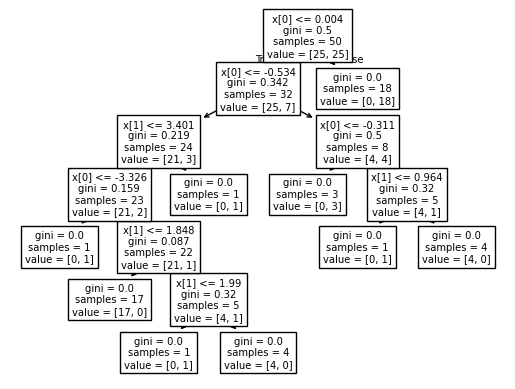

In [21]:
plot_tree(clf1)

[Text(0.578125, 0.9166666666666666, 'x[1] <= -1.285\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.515625, 0.75, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.546875, 0.8333333333333333, 'True  '),
 Text(0.640625, 0.75, 'x[1] <= 0.893\ngini = 0.426\nsamples = 39\nvalue = [27, 12]'),
 Text(0.609375, 0.8333333333333333, '  False'),
 Text(0.40625, 0.5833333333333334, 'x[0] <= 0.514\ngini = 0.496\nsamples = 22\nvalue = [12, 10]'),
 Text(0.25, 0.4166666666666667, 'x[1] <= 0.456\ngini = 0.337\nsamples = 14\nvalue = [11, 3]'),
 Text(0.125, 0.25, 'x[0] <= 0.449\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.0625, 0.08333333333333333, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.1875, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.25, 'x[0] <= 0.12\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.3125, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.4375, 0.08333333333333333, 'gini = 0.0\nsamples 

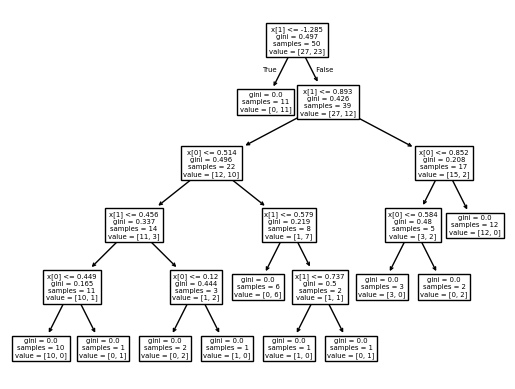

In [22]:
plot_tree(clf2)

[Text(0.3333333333333333, 0.9285714285714286, 'x[1] <= -0.703\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.2222222222222222, 0.7857142857142857, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(0.2777777777777778, 0.8571428571428572, 'True  '),
 Text(0.4444444444444444, 0.7857142857142857, 'x[0] <= -0.057\ngini = 0.312\nsamples = 31\nvalue = [25, 6]'),
 Text(0.38888888888888884, 0.8571428571428572, '  False'),
 Text(0.3333333333333333, 0.6428571428571429, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.5555555555555556, 0.6428571428571429, 'x[1] <= 0.426\ngini = 0.238\nsamples = 29\nvalue = [25, 4]'),
 Text(0.3333333333333333, 0.5, 'x[1] <= 0.036\ngini = 0.444\nsamples = 9\nvalue = [6, 3]'),
 Text(0.2222222222222222, 0.35714285714285715, 'x[0] <= 1.037\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.1111111111111111, 0.21428571428571427, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.3333333333333333, 0.21428571428571427, 'x[0] <= 1.56\ngini = 0.444\nsamples

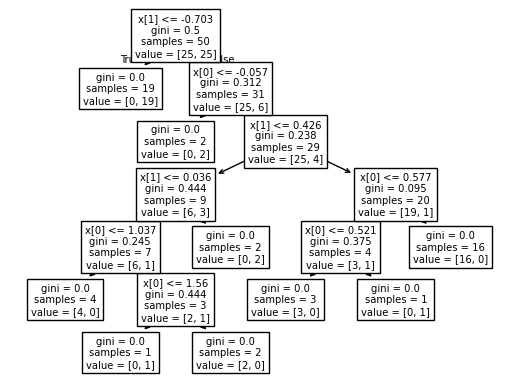

In [23]:
plot_tree(clf3)

In [24]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\ANN_PTROJECT\penve\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [25]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\ANN_PTROJECT\penve\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [26]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\ANN_PTROJECT\penve\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])